# London Raw Parquet EDA

Exploratory analysis for `data/raw/london/london.parquet`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)
sns.set_theme(style="whitegrid")

def find_project_root(start: Path) -> Path:
    for path in [start, *start.parents]:
        if (path / "data" / "raw" / "london" / "london.parquet").exists():
            return path
    raise FileNotFoundError("Could not find data/raw/london/london.parquet")

PROJECT_ROOT = find_project_root(Path.cwd().resolve())
PARQUET_PATH = PROJECT_ROOT / "data" / "raw" / "london" / "london.parquet"

PARQUET_PATH

WindowsPath('C:/Users/lefte/Desktop/GitHub Projects/Thesis_project/data/raw/london/london.parquet')

## Load Data

In [2]:
df = pd.read_parquet(PARQUET_PATH)

print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")
df.head()

Rows: 9,068,241
Columns: 11


,Number,Start date,Start station number,Start station,End date,End station number,End station,Bike number,Bike model,Total duration,Total duration (ms)
0,145666816,2025-01-14 23:59,001043,"Museum of London, Barbican",2025-01-15 00:13,200149,"Watney Street, Shadwell",55223,CLASSIC,14m 30s,870468
1,145666817,2025-01-14 23:59,300015,"Binfield Road, Stockwell",2025-01-15 00:04,300229,"Sidney Road, Stockwell",20325,CLASSIC,5m 7s,307181
2,145666818,2025-01-14 23:59,001068,"Norton Folgate, Liverpool Street",2025-01-15 00:10,001051,"Shoreditch Park, Hoxton",50432,CLASSIC,10m 40s,640755
3,145666819,2025-01-14 23:59,001159,"Berry Street, Clerkenwell",2025-01-15 00:10,001007,"Drury Lane, Covent Garden",56794,CLASSIC,10m 42s,642548
4,145666812,2025-01-14 23:58,200048,"Page Street, Westminster",2025-01-15 00:14,001058,"Edgware Road Station, Marylebone",63546,PBSC_EBIKE,15m 44s,944185


In [3]:
df.info(memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9068241 entries, 0 to 9068240
Data columns (total 11 columns):
 #   Column                Dtype 
---  ------                ----- 
 0   Number                object
 1   Start date            object
 2   Start station number  object
 3   Start station         object
 4   End date              object
 5   End station number    object
 6   End station           object
 7   Bike number           object
 8   Bike model            object
 9   Total duration        object
 10  Total duration (ms)   object
dtypes: object(11)
memory usage: 5.7 GB


## Columns, Missing Values, Duplicates

In [4]:
missing = (
    df.isna().sum()
    .to_frame("missing_count")
    .assign(missing_pct=lambda x: 100 * x["missing_count"] / len(df))
    .sort_values("missing_count", ascending=False)
)

missing

,missing_count,missing_pct
Number,0,0.00
Start date,0,0.00
Start station number,0,0.00
Start station,0,0.00
End date,0,0.00
End station number,0,0.00
End station,0,0.00
Bike number,0,0.00
Bike model,0,0.00
Total duration,0,0.00


In [5]:
print(f"Full duplicate rows: {df.duplicated().sum():,}")

if "Number" in df.columns:
    print(f"Duplicate trip Number values: {df['Number'].duplicated().sum():,}")

Full duplicate rows: 0
Duplicate trip Number values: 0


## Basic Cleaning For EDA

In [6]:
eda = df.copy()

eda["start_datetime"] = pd.to_datetime(eda["Start date"], errors="coerce")
eda["end_datetime"] = pd.to_datetime(eda["End date"], errors="coerce")
eda["duration_ms"] = pd.to_numeric(eda["Total duration (ms)"], errors="coerce")
eda["duration_min"] = eda["duration_ms"] / 60_000

eda["date"] = eda["start_datetime"].dt.date
eda["month"] = eda["start_datetime"].dt.to_period("M").astype(str)
eda["day_name"] = eda["start_datetime"].dt.day_name()
eda["hour"] = eda["start_datetime"].dt.hour
eda["weekday"] = eda["start_datetime"].dt.weekday
eda["is_weekend"] = eda["weekday"].isin([5, 6])

eda[["start_datetime", "end_datetime", "duration_min", "month", "day_name", "hour", "is_weekend"]].head()

,start_datetime,end_datetime,duration_min,month,day_name,hour,is_weekend
0,2025-01-14 23:59:00,2025-01-15 00:13:00,14.51,2025-01,Tuesday,23,False
1,2025-01-14 23:59:00,2025-01-15 00:04:00,5.12,2025-01,Tuesday,23,False
2,2025-01-14 23:59:00,2025-01-15 00:10:00,10.68,2025-01,Tuesday,23,False
3,2025-01-14 23:59:00,2025-01-15 00:10:00,10.71,2025-01,Tuesday,23,False
4,2025-01-14 23:58:00,2025-01-15 00:14:00,15.74,2025-01,Tuesday,23,False


In [7]:
date_checks = pd.Series({
    "missing_start_datetime": eda["start_datetime"].isna().sum(),
    "missing_end_datetime": eda["end_datetime"].isna().sum(),
    "missing_duration_min": eda["duration_min"].isna().sum(),
    "min_start": eda["start_datetime"].min(),
    "max_start": eda["start_datetime"].max(),
    "non_positive_duration": (eda["duration_min"] <= 0).sum(),
})

date_checks

missing_start_datetime                      0
missing_end_datetime                      184
missing_duration_min                      184
min_start                 2025-01-01 00:00:00
max_start                 2025-12-31 23:59:00
non_positive_duration                       0
dtype: object

## Trip Volume Over Time

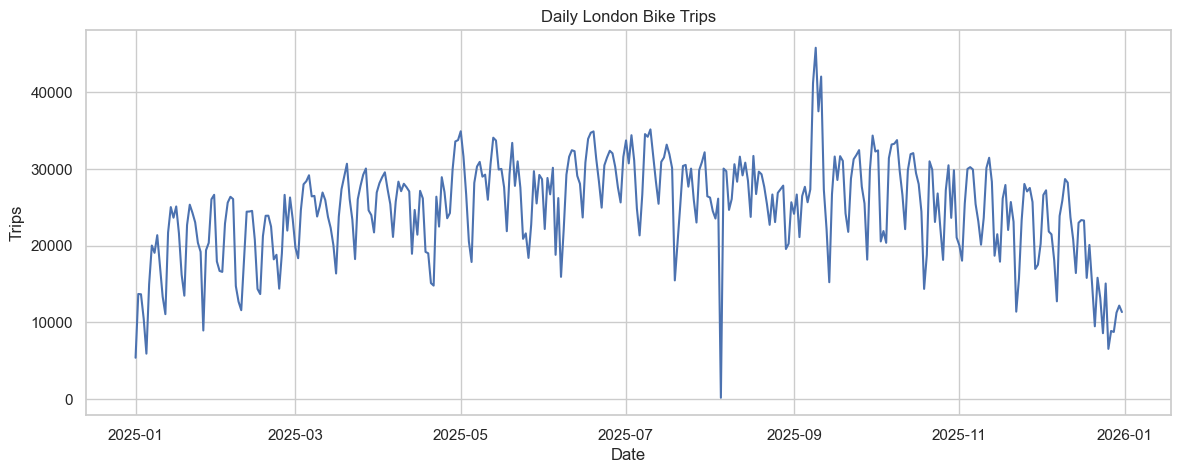

count     365.00
mean    24844.50
std      6403.32
min       188.00
25%     21263.00
50%     25996.00
75%     29342.00
max     45824.00
Name: trips, dtype: float64

In [8]:
daily_trips = eda.groupby("date").size().rename("trips")

ax = daily_trips.plot(figsize=(14, 5), title="Daily London Bike Trips")
ax.set_xlabel("Date")
ax.set_ylabel("Trips")
plt.show()

daily_trips.describe()

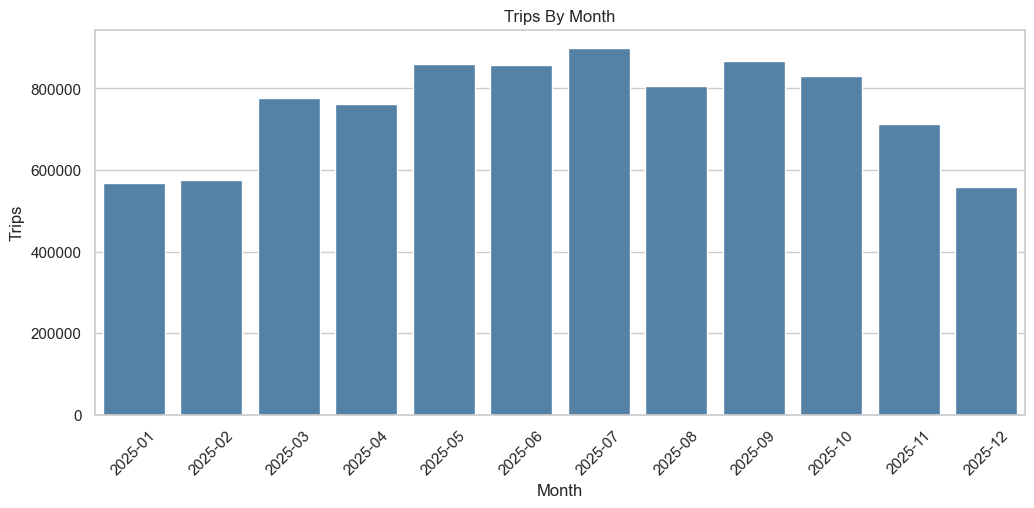

,trips
month,
2025-01,568033
2025-02,574284
2025-03,775127
2025-04,761433
2025-05,859585
2025-06,858439
2025-07,898688
2025-08,804944
2025-09,866350


In [9]:
monthly_trips = eda.groupby("month").size().rename("trips")

plt.figure(figsize=(12, 5))
sns.barplot(x=monthly_trips.index, y=monthly_trips.values, color="steelblue")
plt.title("Trips By Month")
plt.xlabel("Month")
plt.ylabel("Trips")
plt.xticks(rotation=45)
plt.show()

monthly_trips.to_frame()

## Hourly And Weekday Patterns

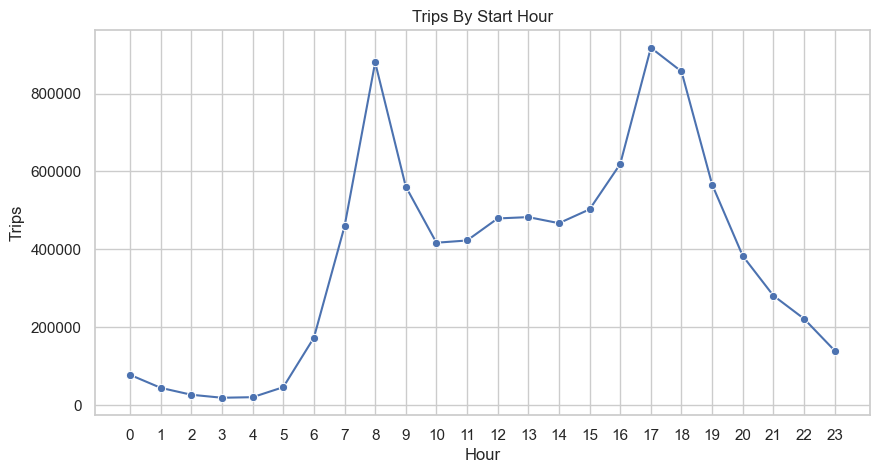

,trips
hour,
0,78010
1,44645
2,26932
3,19246
4,20684
5,46389
6,173335
7,459019
8,879949


In [10]:
hourly_trips = eda.groupby("hour").size().rename("trips")

plt.figure(figsize=(10, 5))
sns.lineplot(x=hourly_trips.index, y=hourly_trips.values, marker="o")
plt.title("Trips By Start Hour")
plt.xlabel("Hour")
plt.ylabel("Trips")
plt.xticks(range(0, 24))
plt.show()

hourly_trips.to_frame()

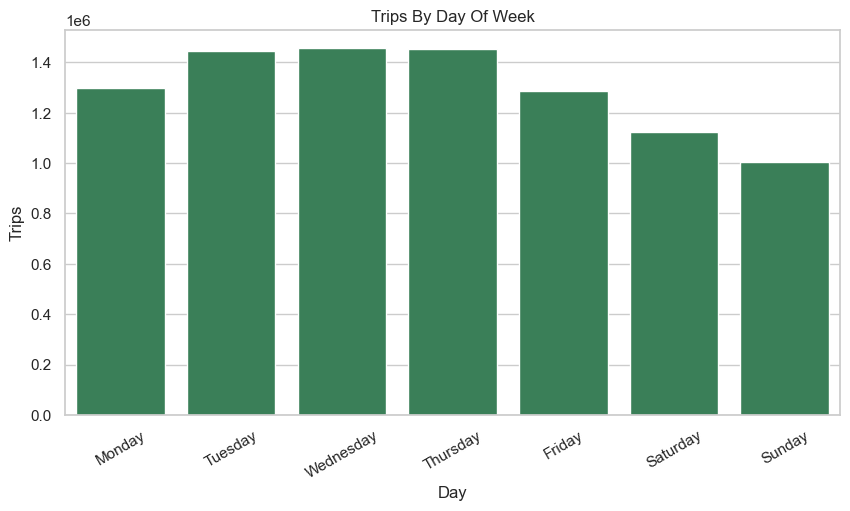

,trips
day_name,
Monday,1297470
Tuesday,1445338
Wednesday,1456153
Thursday,1452191
Friday,1286072
Saturday,1125170
Sunday,1005847


In [11]:
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
weekday_trips = eda.groupby("day_name").size().reindex(day_order).rename("trips")

plt.figure(figsize=(10, 5))
sns.barplot(x=weekday_trips.index, y=weekday_trips.values, color="seagreen")
plt.title("Trips By Day Of Week")
plt.xlabel("Day")
plt.ylabel("Trips")
plt.xticks(rotation=30)
plt.show()

weekday_trips.to_frame()

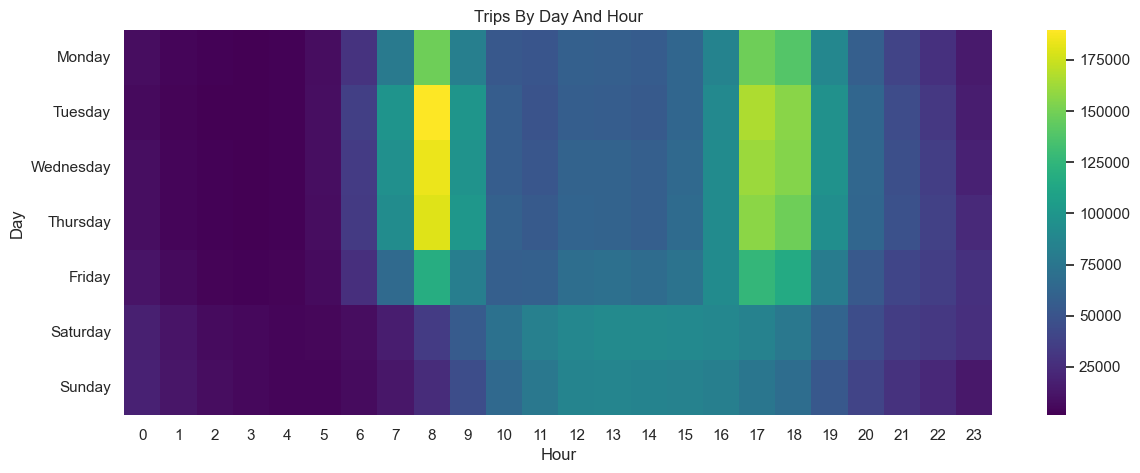

In [12]:
hour_weekday = (
    eda.pivot_table(index="day_name", columns="hour", values="Number", aggfunc="count")
    .reindex(day_order)
)

plt.figure(figsize=(14, 5))
sns.heatmap(hour_weekday, cmap="viridis")
plt.title("Trips By Day And Hour")
plt.xlabel("Hour")
plt.ylabel("Day")
plt.show()

## Trip Duration

In [13]:
eda["duration_min"].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])

count   9068057.00
mean         25.10
std         639.57
min           0.00
1%            1.37
5%            3.29
25%           7.73
50%          13.28
75%          21.56
95%          43.25
99%          83.96
max      301435.21
Name: duration_min, dtype: float64

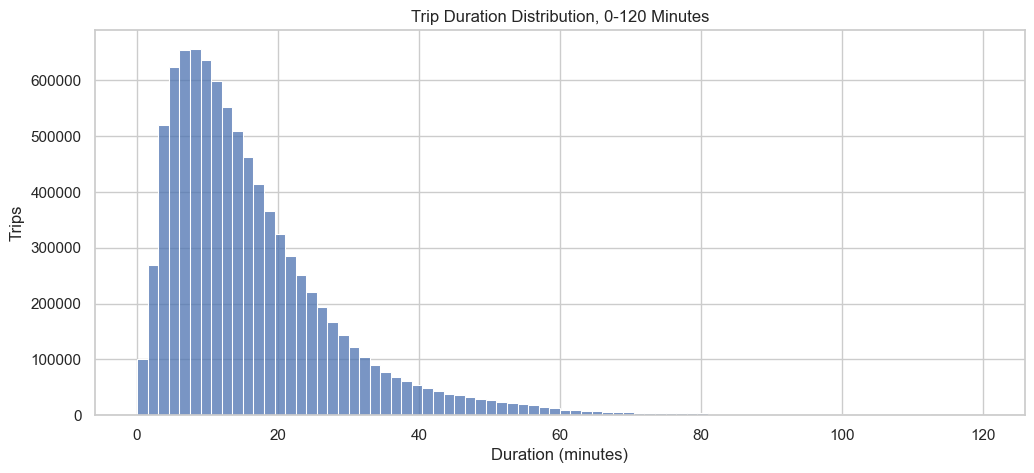

In [14]:
duration_plot = eda.loc[eda["duration_min"].between(0, 120), "duration_min"]

plt.figure(figsize=(12, 5))
sns.histplot(duration_plot, bins=80)
plt.title("Trip Duration Distribution, 0-120 Minutes")
plt.xlabel("Duration (minutes)")
plt.ylabel("Trips")
plt.show()

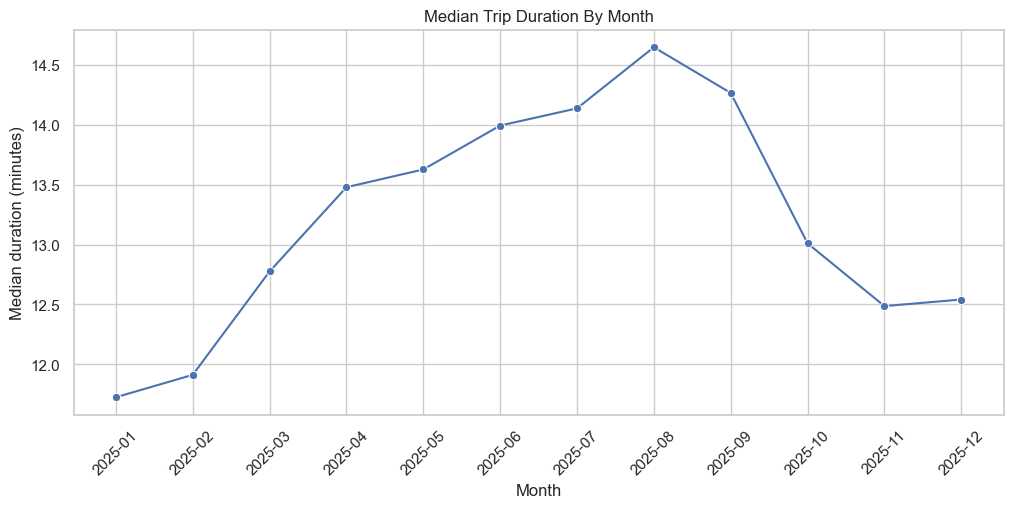

,median_duration_min
month,
2025-01,11.73
2025-02,11.91
2025-03,12.78
2025-04,13.48
2025-05,13.63
2025-06,13.99
2025-07,14.14
2025-08,14.65
2025-09,14.26


In [15]:
duration_by_month = eda.groupby("month")["duration_min"].median().rename("median_duration_min")

plt.figure(figsize=(12, 5))
sns.lineplot(x=duration_by_month.index, y=duration_by_month.values, marker="o")
plt.title("Median Trip Duration By Month")
plt.xlabel("Month")
plt.ylabel("Median duration (minutes)")
plt.xticks(rotation=45)
plt.show()

duration_by_month.to_frame()

## Stations

In [16]:
station_summary = pd.Series({
    "unique_start_stations": eda["Start station"].nunique(),
    "unique_end_stations": eda["End station"].nunique(),
    "unique_start_station_numbers": eda["Start station number"].nunique(),
    "unique_end_station_numbers": eda["End station number"].nunique(),
})

station_summary

unique_start_stations           822
unique_end_stations             826
unique_start_station_numbers    820
unique_end_station_numbers      823
dtype: int64

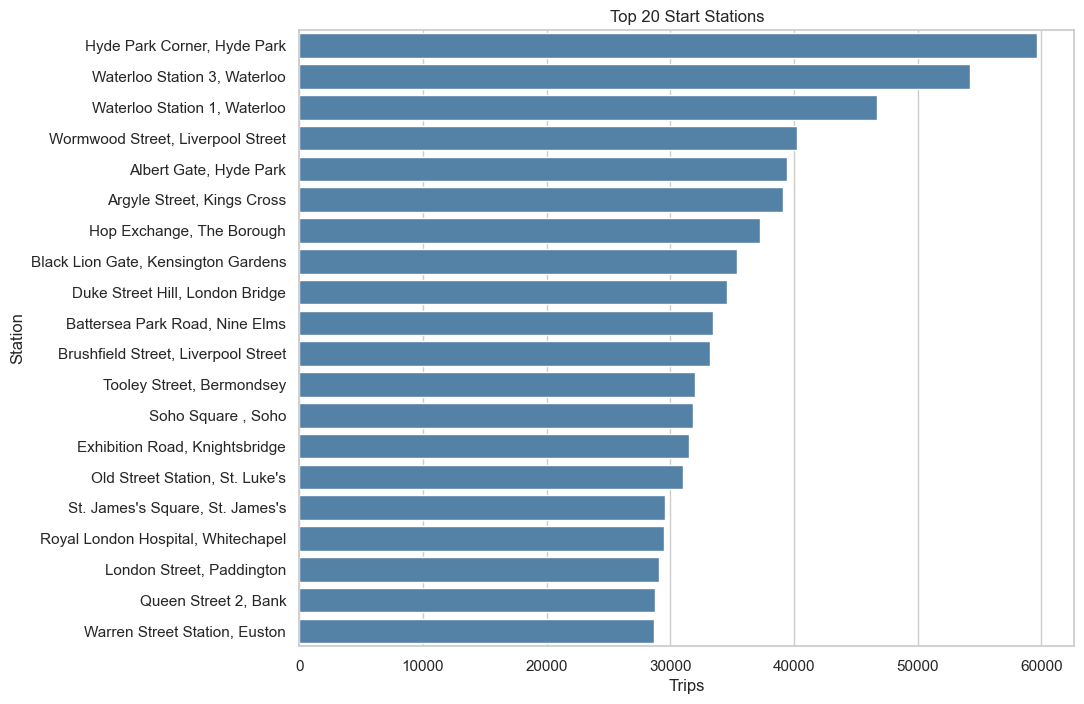

,start_trips
Start station,
"Hyde Park Corner, Hyde Park",59680
"Waterloo Station 3, Waterloo",54196
"Waterloo Station 1, Waterloo",46728
"Wormwood Street, Liverpool Street",40274
"Albert Gate, Hyde Park",39404
"Argyle Street, Kings Cross",39093
"Hop Exchange, The Borough",37250
"Black Lion Gate, Kensington Gardens",35423
"Duke Street Hill, London Bridge",34562


In [17]:
top_start = eda["Start station"].value_counts().head(20)

plt.figure(figsize=(10, 8))
sns.barplot(x=top_start.values, y=top_start.index, color="steelblue")
plt.title("Top 20 Start Stations")
plt.xlabel("Trips")
plt.ylabel("Station")
plt.show()

top_start.to_frame("start_trips")

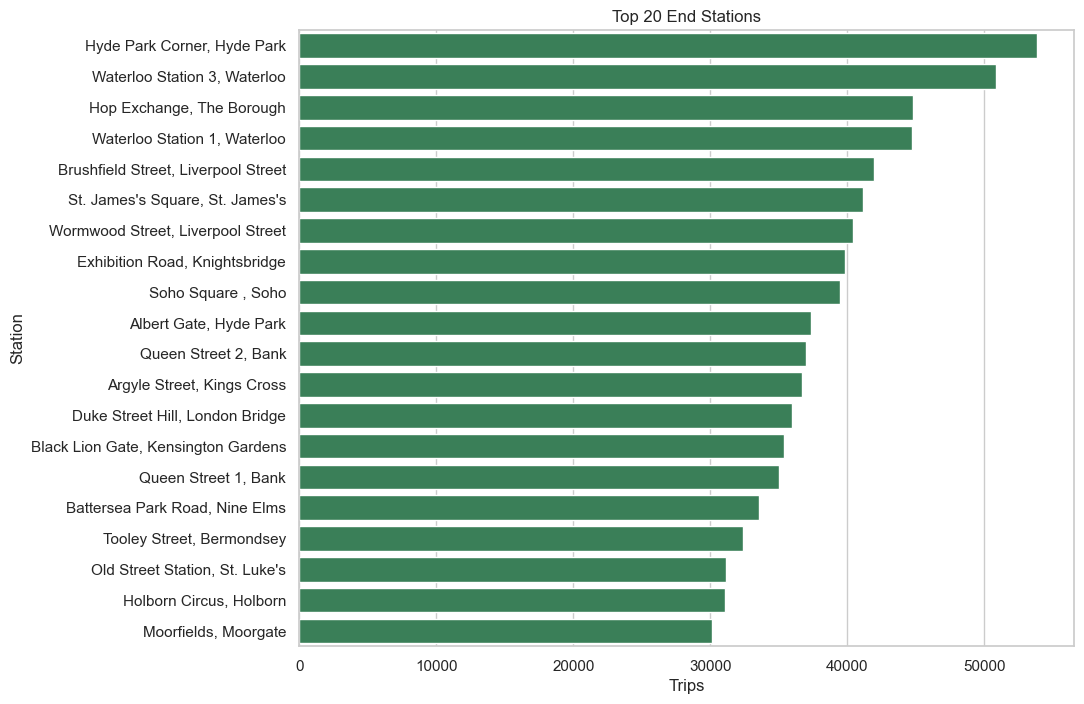

,end_trips
End station,
"Hyde Park Corner, Hyde Park",53871
"Waterloo Station 3, Waterloo",50878
"Hop Exchange, The Borough",44817
"Waterloo Station 1, Waterloo",44732
"Brushfield Street, Liverpool Street",41959
"St. James's Square, St. James's",41105
"Wormwood Street, Liverpool Street",40406
"Exhibition Road, Knightsbridge",39809
"Soho Square , Soho",39432


In [18]:
top_end = eda["End station"].value_counts().head(20)

plt.figure(figsize=(10, 8))
sns.barplot(x=top_end.values, y=top_end.index, color="seagreen")
plt.title("Top 20 End Stations")
plt.xlabel("Trips")
plt.ylabel("Station")
plt.show()

top_end.to_frame("end_trips")

In [19]:
top_routes = (
    eda.groupby(["Start station", "End station"])
    .size()
    .sort_values(ascending=False)
    .head(20)
    .rename("trips")
    .reset_index()
)

top_routes

,Start station,End station,trips
0,"Hyde Park Corner, Hyde Park","Hyde Park Corner, Hyde Park",16940
1,"Albert Gate, Hyde Park","Albert Gate, Hyde Park",7983
2,"Black Lion Gate, Kensington Gardens","Black Lion Gate, Kensington Gardens",7843
3,"Triangle Car Park, Hyde Park","Triangle Car Park, Hyde Park",5283
4,"Podium, Queen Elizabeth Olympic Park","Podium, Queen Elizabeth Olympic Park",5152
5,"Park Lane , Hyde Park","Park Lane , Hyde Park",4249
6,"Aquatic Centre, Queen Elizabeth Olympic Park","Aquatic Centre, Queen Elizabeth Olympic Park",4207
7,"Hyde Park Corner, Hyde Park","Albert Gate, Hyde Park",3156
8,"Palace Gate, Kensington Gardens","Palace Gate, Kensington Gardens",3049
9,"Monier Road, Hackney Wick","Stratford Station, Stratford",2851


## Bikes And Bike Models

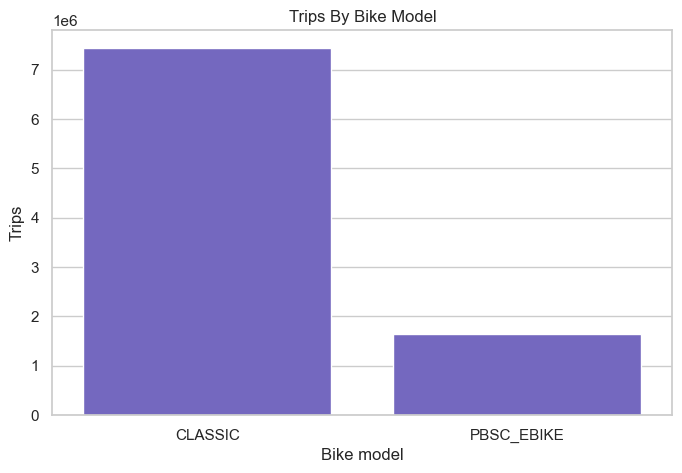

,trips
Bike model,
CLASSIC,7427531
PBSC_EBIKE,1640710


In [20]:
bike_model_counts = eda["Bike model"].value_counts(dropna=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=bike_model_counts.index, y=bike_model_counts.values, color="slateblue")
plt.title("Trips By Bike Model")
plt.xlabel("Bike model")
plt.ylabel("Trips")
plt.show()

bike_model_counts.to_frame("trips")

In [21]:
bike_usage = eda["Bike number"].value_counts().describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99])
bike_usage

count   13676.00
mean      663.08
std       230.74
min         1.00
50%       703.00
75%       833.00
90%       910.00
95%       974.00
99%      1141.00
max      1403.00
Name: count, dtype: float64

## Data Quality Checks

In [22]:
quality_checks = pd.Series({
    "same_start_end_station": (eda["Start station number"] == eda["End station number"]).sum(),
    "end_before_start": (eda["end_datetime"] < eda["start_datetime"]).sum(),
    "duration_over_24h": (eda["duration_min"] > 24 * 60).sum(),
    "duration_under_1min": eda["duration_min"].between(0, 1, inclusive="left").sum(),
})

quality_checks

same_start_end_station    305702
end_before_start              66
duration_over_24h           6225
duration_under_1min        71631
dtype: int64

In [23]:
eda.loc[
    eda["duration_min"].nlargest(10).index,
    ["Number", "Start date", "End date", "Start station", "End station", "Bike number", "Bike model", "duration_min"],
]

,Number,Start date,End date,Start station,End station,Bike number,Bike model,duration_min
3913490,149088197,2025-06-02 05:31,2025-12-28 12:26,"London Fields, Hackney Central_OLD","Shoreditch Park, Hoxton",35180,CLASSIC,301435.21
3659639,149347521,2025-06-11 18:28,2025-12-22 19:18,"London Fields, Hackney Central_OLD","Berry Street, Clerkenwell",54802,CLASSIC,279469.29
3769522,149235249,2025-06-07 19:01,2025-12-13 17:22,"Old Brompton Road, South Kensington","Crabtree Lane, Fulham",23035,CLASSIC,272120.61
3621888,149386017,2025-06-12 21:13,2025-12-17 16:12,"Great Dover Street, The Borough","Bermondsey Station, Bermondsey",53793,CLASSIC,270479.20
4261641,149610933,2025-06-20 05:52,2025-12-18 20:56,"The Blue, Bermondsey","Alfreda Street, Battersea Park",56882,CLASSIC,261603.63
3634835,149372810,2025-06-12 15:52,2025-12-10 14:42,"Portugal Street, Holborn",Mechanical Workshop Penton,22754,CLASSIC,260630.78
3596040,149412603,2025-06-13 18:39,2025-12-09 16:17,"Warwick Avenue Station, Maida Vale","The Metropolitan, Portobello",59171,CLASSIC,257678.22
3903620,149098255,2025-06-02 12:01,2025-11-26 17:21,"Lambeth Palace Road, Waterloo","Risinghill Street, Angel",53262,CLASSIC,255259.64
4083074,149794865,2025-06-26 01:28,2025-12-19 08:28,"Chicheley Street, South Bank","Boston Place, Marylebone",21263,CLASSIC,253919.20
4054668,149823991,2025-06-26 20:30,2025-12-18 14:06,"Tooley Street, Bermondsey","Gauden Road, Clapham",57927,CLASSIC,251675.96
